In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:

# File paths
file_fuel_1 = 'Fuel_Level_Part_1-1.csv'
file_fuel_2 = 'Fuel_Level_Part_2-1.csv'
file_invoices = 'Invoices-1.csv'
file_locations = 'Locations-1.csv'
file_tanks = 'Tanks-1.csv'

# Load the csv files
df_fuel_1 = pd.read_csv(file_fuel_1)
df_fuel_2 = pd.read_csv(file_fuel_2)
df_invoices = pd.read_csv(file_invoices)
df_locations = pd.read_csv(file_locations)
df_tanks = pd.read_csv(file_tanks)

print("Files loaded.")

Files loaded.


In [10]:

# Show the first few rows of each table
print("Fuel Level 1:")
display(df_fuel_1.head())
print("Fuel Level 2:")
display(df_fuel_2.head())
print("Invoices:")
display(df_invoices.head())
print("Locations:")
display(df_locations.head())
print("Tanks:")
display(df_tanks.head())

Fuel Level 1:


,Tank ID,Fuel Level,Time stamp
0,T 12,27161.0,1/1/2017 0:10
1,T 12,27017.0,1/1/2017 0:25
2,T 12,26934.0,1/1/2017 0:40
3,T12,NaN,1/1/2017 0:45
4,T 12,26786.0,1/1/2017 0:55


Fuel Level 2:


,Tank ID,Fuel_Level,Timestamp
0,T 32,22327,1/1/2017 0:05
1,T 20,25215,1/1/2017 0:07
2,T 10,25700,1/1/2017 0:09
3,T 11,25685,1/1/2017 0:10
4,T 14,27138,1/1/2017 0:10


Invoices:


,Invoice Date,Invoice ID,Invoice Gas Station Location,Gross Purchase Cost,Amount Purchased,Fuel Type
0,1/2/2017,10000.0,1,7570.820,6609.600,G
1,1/2/2017,10001.0,1,12491.853,9338.736,D
2,1/2/2017,10002.0,1,NaN,NaN,NaN
3,1/2/2017,10002.0,2,17034.345,13377.824,D
4,1/2/2017,NaN,2,NaN,NaN,NaN


Locations:


,Gas Station Location,Gas Station Name,Gas Station Address,Gas Station Latitude,Gas Station Longitude
0,1,EastMount,"386 Upper Gage Ave, Hamilton, ON L8V 4H9, Canada",43.234670,-79.836510
1,2,Eastgate,"75 Centennial Pkwy N E5, Hamilton, ON L8E 2P2,...",43.230700,-79.763930
2,3,Central,"80 Park St N, Hamilton, ON L8R 2M9, Canada",43.260260,-79.870580
3,4,Chedoke,"16 McMaster Ave, Dundas, ON L9H 0A8, Canada",43.261849,-79.937057
4,5,Mountain View,"985 Scenic Dr, Hamilton, ON L9C 1H7, Canada",43.244910,-79.921850


Tanks:


,Tank ID,Tank Location,Tank Number,Tank Type,Tank Capacity
0,T 10,1,1,U,40000
1,T 11,1,2,U,40000
2,T 12,1,3,D,40000
3,T 13,1,4,P,40000
4,T 14,1,5,U,40000


In [11]:
# Rename columns to be consistent
df_fuel_1.rename(columns={'Fuel Level': 'fuel_level', 'Time stamp': 'timestamp', 'Tank ID': 'tank_id'}, inplace=True)
df_fuel_2.rename(columns={'Fuel_Level': 'fuel_level', 'Timestamp': 'timestamp', 'Tank ID': 'tank_id'}, inplace=True)


In [12]:
# Combine the two fuel dataframes
df_fuel = pd.concat([df_fuel_1, df_fuel_2], ignore_index=True)

# Convert timestamp column to datetime type
df_fuel['timestamp'] = pd.to_datetime(df_fuel['timestamp'])

# Sort by tank and time
df_fuel.sort_values(by=['tank_id', 'timestamp'], inplace=True)

print("Fuel data combined and cleaned.")
df_fuel.info()

Fuel data combined and cleaned.
<class 'pandas.core.frame.DataFrame'>
Index: 1859660 entries, 885153 to 111
Data columns (total 3 columns):
 #   Column      Dtype         
---  ------      -----         
 0   tank_id     object        
 1   fuel_level  float64       
 2   timestamp   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 56.8+ MB


In [13]:
# Standardize all column names to lowercase with underscores
df_tanks.columns = [col.lower().replace(' ', '_') for col in df_tanks.columns]
df_locations.columns = [col.lower().replace(' ', '_') for col in df_locations.columns]
df_invoices.columns = [col.lower().replace(' ', '_') for col in df_invoices.columns]


In [14]:

# Merge fuel data with tank details
fuel_data = pd.merge(df_fuel, df_tanks, on='tank_id', how='left')

# Merge the result with location details
fuel_data = pd.merge(fuel_data, df_locations, left_on='tank_location', right_on='gas_station_location', how='left')

In [15]:

# Prepare invoices data
df_invoices['invoice_date'] = pd.to_datetime(df_invoices['invoice_date'])
df_invoices['price_per_liter'] = df_invoices['gross_purchase_cost'] / df_invoices['amount_purchased']

print("Master dataframe created and invoices prepped.")

Master dataframe created and invoices prepped.


In [16]:
# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 8)

# Choose a tank and date range to plot
target_tank_id = 'T 12'
start_date = '2017-01-01'
end_date = '2017-01-15'

# Filter data for the plot
tank_df = fuel_data[
    (fuel_data['tank_id'] == target_tank_id) &
    (fuel_data['timestamp'] >= start_date) &
    (fuel_data['timestamp'] <= end_date)
].copy()


In [17]:

# Get tank info to find the right invoices
tank_info = df_tanks.loc[df_tanks['tank_id'] == target_tank_id]
target_location_id = tank_info['tank_location'].iloc[0]
target_fuel_type = tank_info['tank_type'].iloc[0]

# Filter invoices for this tank's deliveries
deliveries_df = df_invoices[
    (df_invoices['invoice_gas_station_location'] == target_location_id) &
    (df_invoices['fuel_type'] == target_fuel_type) &
    (df_invoices['invoice_date'] >= start_date) &
    (df_invoices['invoice_date'] <= end_date)
].copy()



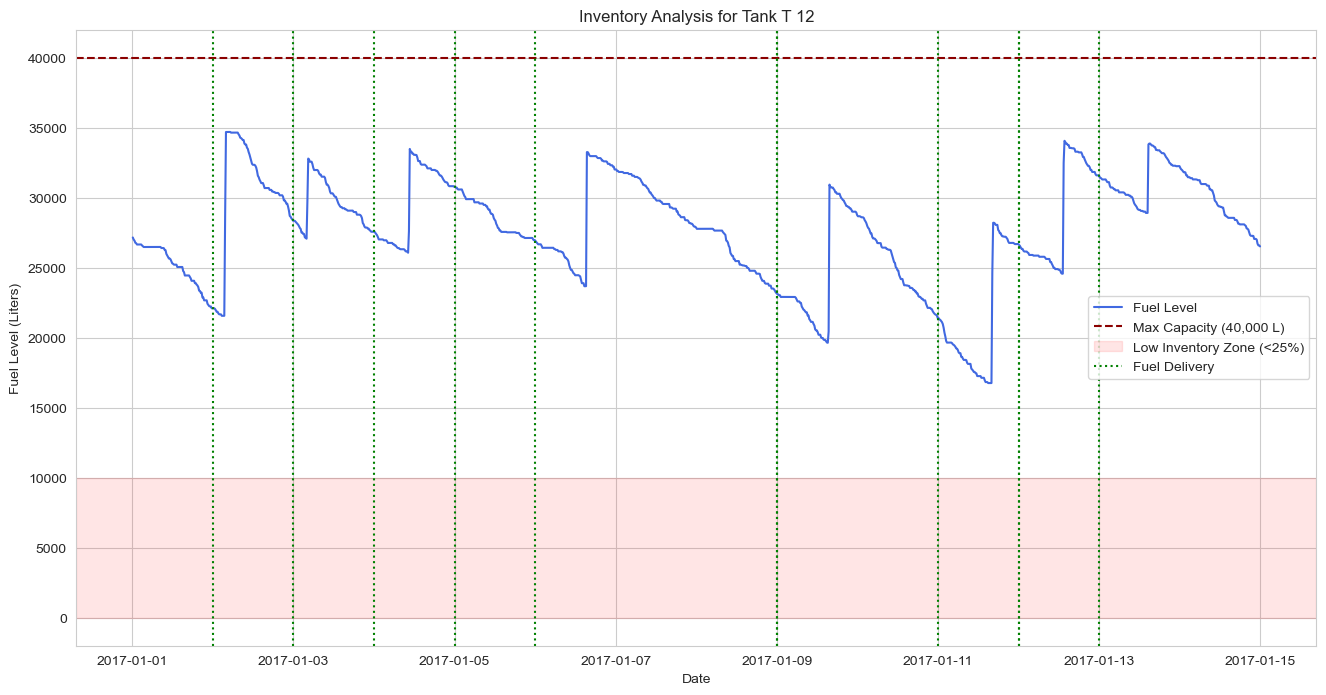

In [18]:
# Plot fuel level over time
sns.lineplot(x='timestamp', y='fuel_level', data=tank_df, label='Fuel Level', color='royalblue')

# Add lines for capacity and low fuel
tank_capacity = tank_df['tank_capacity'].iloc[0]
plt.axhline(y=tank_capacity, color='darkred', linestyle='--', label=f'Max Capacity ({tank_capacity:,.0f} L)')
plt.axhspan(0, tank_capacity * 0.25, color='red', alpha=0.1, label='Low Inventory Zone (<25%)')

# Add vertical lines for deliveries, using one label for all
delivery_label_added = False
for delivery_date in deliveries_df['invoice_date']:
    if not delivery_label_added:
        plt.axvline(x=delivery_date, color='green', linestyle=':', label='Fuel Delivery')
        delivery_label_added = True
    else:
        plt.axvline(x=delivery_date, color='green', linestyle=':')

# Add titles and labels
plt.title(f'Inventory Analysis for Tank {target_tank_id}')
plt.xlabel('Date')
plt.ylabel('Fuel Level (Liters)')
plt.legend()
plt.show()

In [19]:
# Function to get discount rate based on liters
def get_discount_rate(liters):
    if liters >= 40000:
        return 0.04
    elif liters >= 25000:
        return 0.03
    elif liters >= 15000:
        return 0.02
    else:
        return 0.00


In [20]:
# Remove rows with missing values and make a copy
df_invoices_clean = df_invoices.dropna(subset=['amount_purchased', 'gross_purchase_cost']).copy()

# Calculate the discount and savings for each purchase
df_invoices_clean['discount_rate_achieved'] = df_invoices_clean['amount_purchased'].apply(get_discount_rate)
df_invoices_clean['savings_achieved'] = df_invoices_clean['amount_purchased'] * df_invoices_clean['discount_rate_achieved']


In [21]:
# Sum up savings by station
current_savings = df_invoices_clean.groupby('invoice_gas_station_location')['savings_achieved'].sum().reset_index()


In [22]:
# Add station names for the report
current_savings = pd.merge(current_savings, df_locations, left_on='invoice_gas_station_location', right_on='gas_station_location')
current_savings = current_savings[['gas_station_name', 'savings_achieved']]
current_savings.rename(columns={'gas_station_name': 'Gas Station', 'savings_achieved': 'Total Savings Achieved (CAD)'}, inplace=True)
current_savings = current_savings.sort_values(by='Total Savings Achieved (CAD)', ascending=False)


In [23]:
# Display results
print("Total Historical Savings by Gas Station")
current_savings['Total Savings Achieved (CAD)'] = current_savings['Total Savings Achieved (CAD)'].map('${:,.2f}'.format)
display(current_savings)

Total Historical Savings by Gas Station


,Gas Station,Total Savings Achieved (CAD)
0,EastMount,"$190,587.38"
1,Eastgate,"$10,296.32"
2,Central,"$1,955.05"
5,Oakville,"$1,461.90"
7,Chappel,"$1,335.40"
3,Chedoke,$343.37
4,Mountain View,$0.00
6,Circle,$0.00


In [24]:
# Calculate fuel level change between readings
fuel_data['level_change'] = fuel_data.groupby('tank_id')['fuel_level'].diff()

# Filter for sales (negative changes)
sales_df = fuel_data[fuel_data['level_change'] < 0].copy()

# Calculate total sales per day for each tank
daily_consumption = sales_df.groupby(['tank_id', pd.Grouper(key='timestamp', freq='D')])['level_change'].sum().abs().reset_index()
daily_consumption.rename(columns={'level_change': 'daily_volume_sold'}, inplace=True)


In [25]:
# Get average daily sales for each tank
avg_tank_consumption = daily_consumption.groupby('tank_id')['daily_volume_sold'].mean().reset_index()
avg_tank_consumption.rename(columns={'daily_volume_sold': 'avg_daily_consumption'}, inplace=True)


In [26]:
# Map tank types ('U'/'P') to invoice types ('G')
fuel_map = {'U': 'G', 'P': 'G', 'D': 'D'}
df_tanks['fuel_type'] = df_tanks['tank_type'].map(fuel_map)


In [27]:
# Get total capacity by location and fuel type
capacity_summary = df_tanks.groupby(['tank_location', 'fuel_type'])['tank_capacity'].sum().reset_index()


In [28]:
# Get total consumption by location and fuel type
consumption_summary = pd.merge(df_tanks[['tank_id', 'tank_location', 'fuel_type']], avg_tank_consumption, on='tank_id')
consumption_summary = consumption_summary.groupby(['tank_location', 'fuel_type'])['avg_daily_consumption'].sum().reset_index()


In [29]:
# Get total purchase info from invoices
purchase_summary = df_invoices_clean.groupby(['invoice_gas_station_location', 'fuel_type']) \
                                    .agg(total_liters_purchased=('amount_purchased', 'sum'),
                                         savings_achieved=('savings_achieved', 'sum')).reset_index()


In [30]:
# Combine the summaries
analysis_df = pd.merge(capacity_summary, consumption_summary, on=['tank_location', 'fuel_type'])
analysis_df = pd.merge(analysis_df, purchase_summary, left_on=['tank_location', 'fuel_type'], right_on=['invoice_gas_station_location', 'fuel_type'])


In [31]:
# Calculate potential savings
analysis_df['potential_discount_rate'] = analysis_df['tank_capacity'].apply(get_discount_rate)
analysis_df['potential_savings'] = analysis_df['total_liters_purchased'] * analysis_df['potential_discount_rate']
analysis_df['additional_savings_possible'] = analysis_df['potential_savings'] - analysis_df['savings_achieved']


In [32]:
# Create final report table
final_report = pd.merge(analysis_df, df_locations, left_on='tank_location', right_on='gas_station_location')
final_summary = final_report.groupby('gas_station_name')[['savings_achieved', 'potential_savings', 'additional_savings_possible']].sum().sort_values(by='additional_savings_possible', ascending=False)


The table below compares the **Savings Achieved** with the **Potential Savings**, showing the possible additional savings. 

#### Recommendations: 

Our recommendation is to move from smaller orders to larger orders, minimizing the frequency. This will eventally maximize the use of existing tank capacity. As shown in the chart below, stations like **EastMount** and **Eastgate** could save **$438,959** and **$241,040** respectively by adopting this policy.

In [33]:
# Format for display
for col in final_summary.columns:
    final_summary[col] = final_summary[col].map('${:,.2f}'.format)

print("Savings Analysis: Actual vs. Potential")
display(final_summary)

Savings Analysis: Actual vs. Potential


,savings_achieved,potential_savings,additional_savings_possible
gas_station_name,,,
EastMount,"$190,587.38","$629,546.77","$438,959.39"
Eastgate,"$10,296.32","$251,336.54","$241,040.22"
Chedoke,$343.37,"$128,443.45","$128,100.08"
Mountain View,$0.00,"$64,753.40","$64,753.40"
Central,"$1,955.05","$25,660.01","$23,704.96"
Oakville,"$1,461.90","$17,106.10","$15,644.21"
Chappel,"$1,335.40","$11,351.73","$10,016.34"
Circle,$0.00,$0.00,$0.00


In [34]:
# Get day of week from invoice date
df_invoices_clean['day_of_week'] = df_invoices_clean['invoice_date'].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Calculate average price for each day
avg_price_by_day = df_invoices_clean.groupby('day_of_week')['price_per_liter'].mean().reindex(day_order).reset_index()
avg_price_by_day.rename(columns={'price_per_liter': 'average_price'}, inplace=True)
best_day = avg_price_by_day.loc[avg_price_by_day['average_price'].idxmin()]


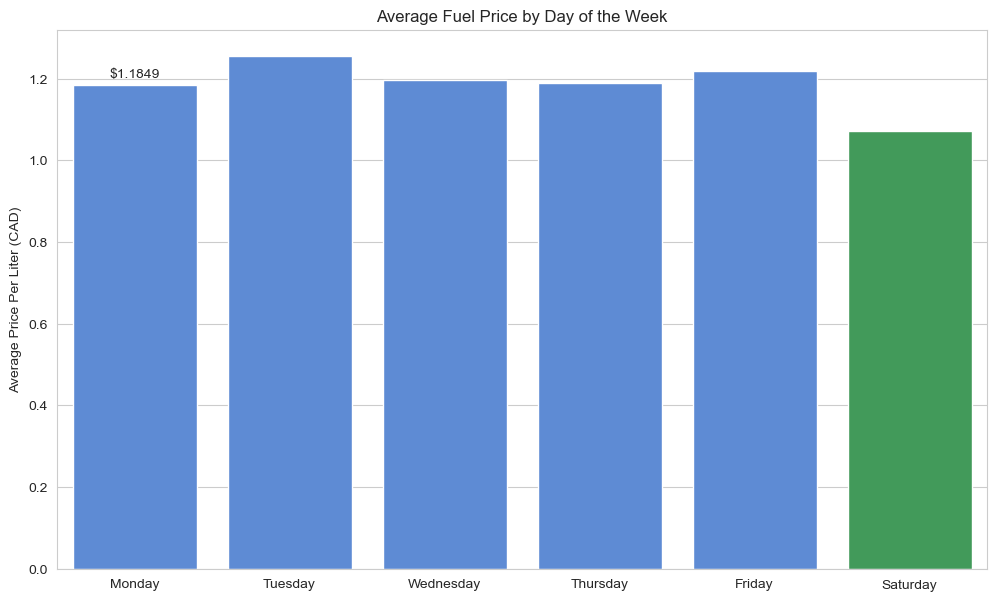

In [35]:

# Prepare data for plotting (remove Sunday since it has no data)
avg_price_plot_data = avg_price_by_day.dropna()

# Create a list of colors to highlight the best day
colors = []
for day in avg_price_plot_data['day_of_week']:
    if day == best_day['day_of_week']:
        colors.append('#34A853') # Green for best day
    else:
        colors.append('#4A86E8') # Blue for other days

# Create bar plot
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='day_of_week', y='average_price', data=avg_price_plot_data, palette=colors, hue='day_of_week', dodge=False, legend=False)

# Add titles and labels
plt.title('Average Fuel Price by Day of the Week')
plt.xlabel('')
plt.ylabel('Average Price Per Liter (CAD)')

# Add price labels on top of bars
ax.bar_label(ax.containers[0], fmt='$%.4f', padding=3)

plt.show()


Identifying the Best Day for Fuel Orders

The analysis shows that **Saturday** has the lowest average price per liter. 

#### Recommendation:
We would recommended that the company should shift fuel purchase orders to Saturdays in order to capitalize on these lower average prices.

In [36]:

# Display summary table
print("Summary of Weekly Fuel Prices")
display_table = avg_price_by_day.set_index('day_of_week')
display_table['average_price'] = display_table['average_price'].map('${:,.4f}'.format).replace('$nan', 'No Deliveries')
display(display_table)

Summary of Weekly Fuel Prices


,average_price
day_of_week,
Monday,$1.1849
Tuesday,$1.2563
Wednesday,$1.1956
Thursday,$1.1901
Friday,$1.2176
Saturday,$1.0721
Sunday,No Deliveries


In [37]:
# Financial assumptions
COST_OF_NEW_TANK = 75000
ANALYSIS_PERIOD_YEARS = 5




In [38]:
# Find stations with capacity under 40,000L
constrained_locations = analysis_df[analysis_df['tank_capacity'] < 40000].copy()

# Calculate potential increase in discount rate
constrained_locations['current_max_rate'] = constrained_locations['tank_capacity'].apply(get_discount_rate)
constrained_locations['discount_rate_increase'] = 0.04 - constrained_locations['current_max_rate']

# Calculate potential savings and payback period
constrained_locations['potential_annual_savings'] = constrained_locations['total_liters_purchased'] * constrained_locations['discount_rate_increase']
constrained_locations['payback_period_years'] = COST_OF_NEW_TANK / constrained_locations['potential_annual_savings']


In [39]:
print("Feasibility Analysis for Adding New Tanks")

# Create final analysis table
investment_analysis = pd.merge(constrained_locations, df_locations, left_on='tank_location', right_on='gas_station_location')
investment_analysis = investment_analysis[['gas_station_name', 'fuel_type', 'tank_capacity', 'potential_annual_savings', 'payback_period_years']].sort_values(by='payback_period_years')

# Format columns for display
investment_analysis['tank_capacity'] = investment_analysis['tank_capacity'].map('{:,.0f} L'.format)
investment_analysis['potential_annual_savings'] = investment_analysis['potential_annual_savings'].map('${:,.2f}'.format)
investment_analysis['payback_period_years'] = investment_analysis['payback_period_years'].map('{:.2f} years'.format)

display(investment_analysis)

Feasibility Analysis for Adding New Tanks


,gas_station_name,fuel_type,tank_capacity,potential_annual_savings,payback_period_years
3,Mountain View,G,"25,000 L","$13,467.13",5.57 years
2,Mountain View,D,"25,000 L","$8,117.34",9.24 years
0,Central,D,"30,000 L","$4,318.15",17.37 years
1,Central,G,"30,000 L","$4,235.19",17.71 years
6,Circle,G,"5,000 L","$3,742.51",20.04 years
4,Oakville,D,"30,000 L",$546.30,137.29 years
5,Circle,D,"5,000 L",$443.29,169.19 years


#### Evaluating the Feasibility of Adding New Tanks

**Recommendation:** The analysis indicates that investing in new tanks is **not financially viable**. The shortest payback period is 5.57 years for Mountain View, which is too long for this investment. The company's focus should be on optimizing the use of its current assets.

In [40]:
# --- Final Summary Dashboard Visualization ---

# Prepare the savings data (grouped bar chart data)
summary_data = final_report.groupby('gas_station_name')[['savings_achieved', 'additional_savings_possible']].sum()
summary_data = summary_data.sort_values(by='additional_savings_possible', ascending=False)
summary_data.rename(columns={'savings_achieved': 'Savings Achieved', 'additional_savings_possible': 'Additional Savings Possible'}, inplace=True)


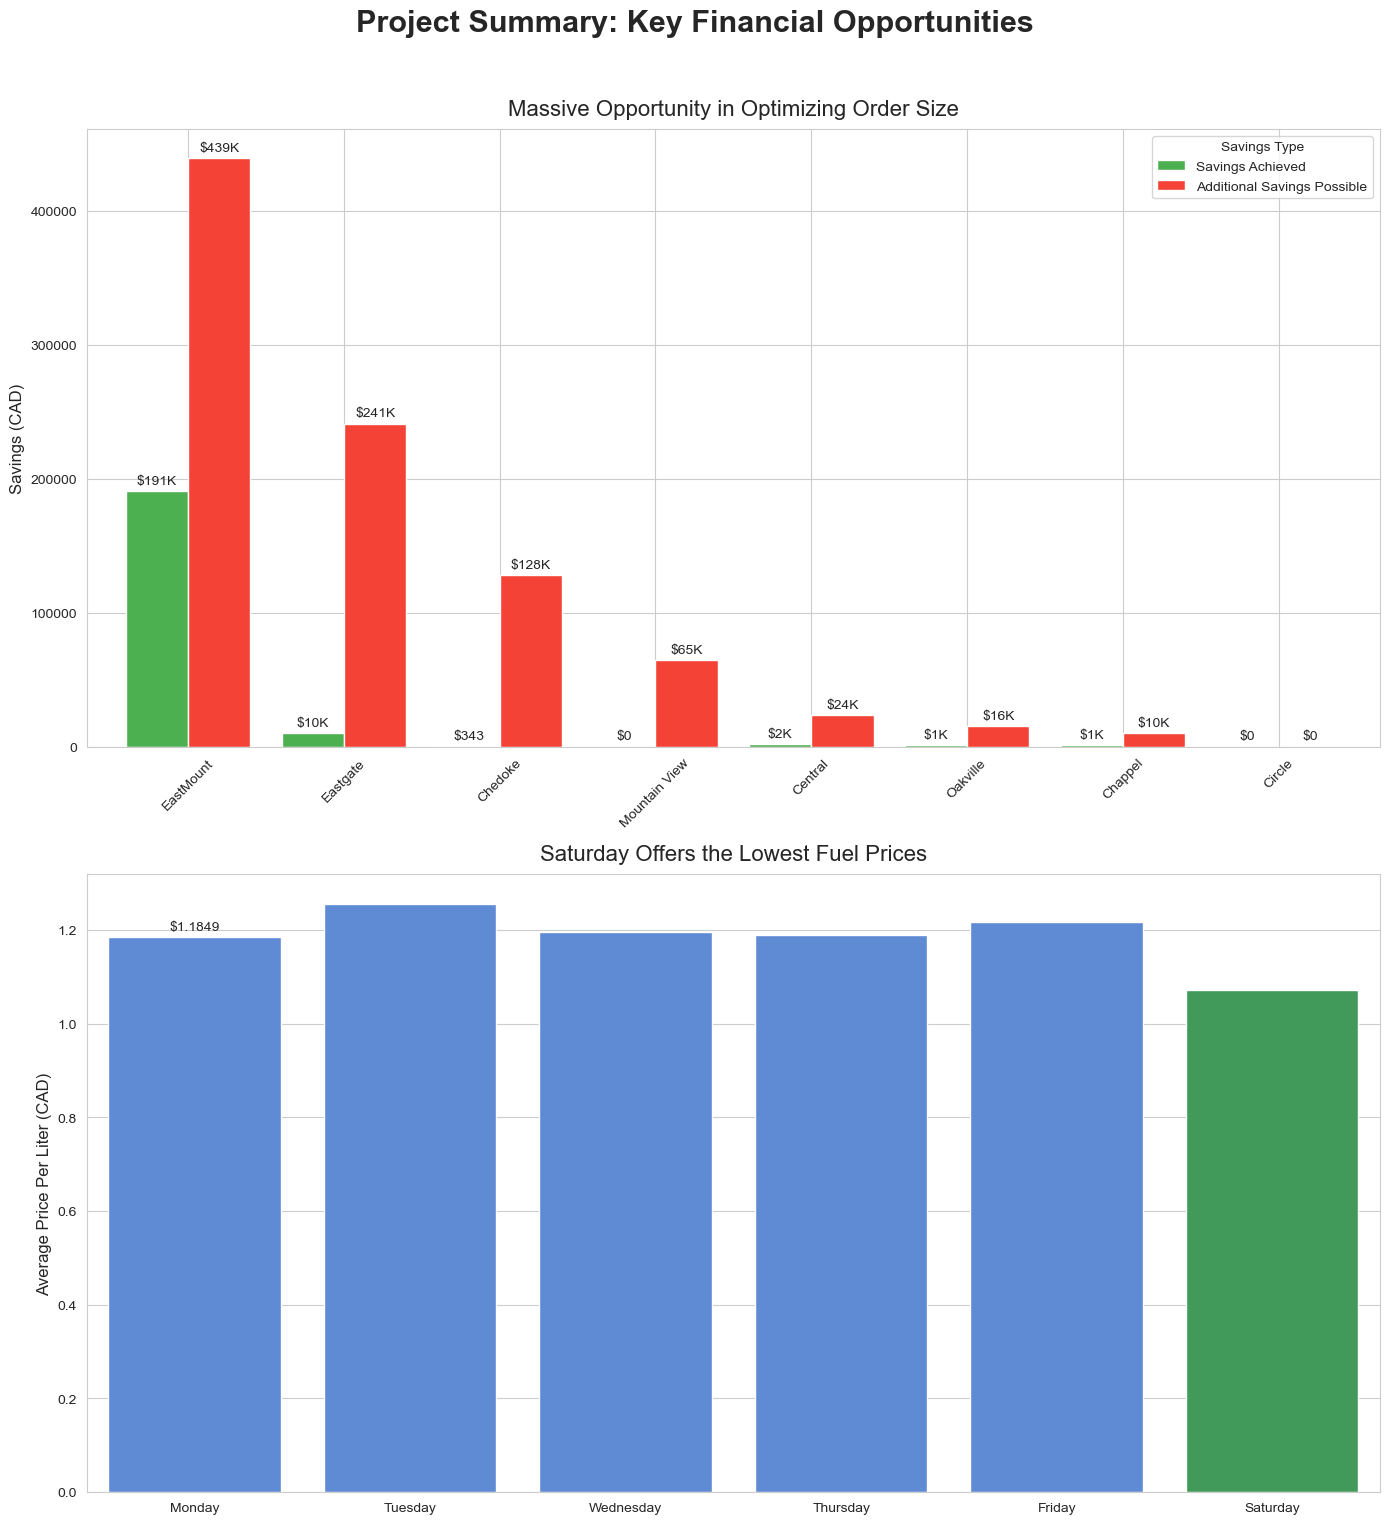

In [41]:
# --- Create a 2-in-1 Figure (Dashboard) ---
# Create a figure with two subplots, one on top of the other
fig, axes = plt.subplots(2, 1, figsize=(14, 16))
fig.suptitle('Project Summary: Key Financial Opportunities', fontsize=22, weight='bold')


# Prepare the daily price data (bar chart data)
avg_price_plot_data = avg_price_by_day.dropna()
best_day_name = avg_price_by_day.loc[avg_price_by_day['average_price'].idxmin()]['day_of_week']
price_colors = ['#4A86E8' if day != best_day_name else '#34A853' for day in avg_price_plot_data['day_of_week']]


# --- Plot 1: Actual vs. Potential Savings (Top) ---
summary_data.plot(kind='bar', stacked=False, ax=axes[0], color=['#4CAF50', '#F44336'], width=0.8)
axes[0].set_title('Massive Opportunity in Optimizing Order Size', fontsize=16, pad=10)
axes[0].set_ylabel('Savings (CAD)', fontsize=12)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Savings Type')
# Add labels to the bars
for container in axes[0].containers:
    labels = [f'${v/1000:,.0f}K' if v > 1000 else f'${v:,.0f}' for v in container.datavalues]
    axes[0].bar_label(container, labels=labels, label_type='edge', padding=3)

# --- Plot 2: Average Price by Day (Bottom) ---
sns.barplot(x='day_of_week', y='average_price', data=avg_price_plot_data, palette=price_colors, hue='day_of_week', dodge=False, legend=False, ax=axes[1])
axes[1].set_title('Saturday Offers the Lowest Fuel Prices', fontsize=16, pad=10)
axes[1].set_ylabel('Average Price Per Liter (CAD)', fontsize=12)
axes[1].set_xlabel('')
# Add labels to the bars
axes[1].bar_label(axes[1].containers[0], fmt='$%.4f', padding=3)

# Adjust layout and show the final dashboard
plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust for the main title
plt.show()